<a href="https://colab.research.google.com/github/hpark0724/ds-study/blob/main/python-eda-sephora.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##

## Sephora 화장품 데이터 EDA
> seaborn 내장 mpg 데이터로 배운 단변량 EDA 기법을, Sephora 데이터셋에 적용
- [x] price, rating, loves_count 분포 확인
- [x] skew/kurt로 치우침 비교
- [x] mpg와 차이점 분석

데이터 출처: [Sephora Products and Skincare Reviews](https://www.kaggle.com/datasets/nadyinky/sephora-products-and-skincare-reviews)

강의 출처: 부스트코스 [모두를 위한 데이터 사이언스](https://www.boostcourse.org/ds101/joinLectures/261910) — 5.3 수치형 변수의 탐색적 데이터 분석




### 라이브러리 & 데이터 불러오기

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
print(pd.__version__)
print(sns.__version__)

2.2.3
0.13.2


In [5]:
import os, getpass

os.environ['KAGGLE_USERNAME'] = input("Kaggle 사용자명(username) 입력: ")
os.environ['KAGGLE_KEY'] = getpass.getpass("Kaggle API 키(key) 입력: ")

Kaggle 사용자명(username) 입력: hpark0724
Kaggle API 키(key) 입력: ··········


## Kaggle에서 세포라 데이터 가져오기

In [6]:
!pip install Kaggle
!kaggle datasets download -d nadyinky/sephora-products-and-skincare-reviews
!unzip sephora-products-and-skincare-reviews.zip -d sephora_dataYyy

Dataset URL: https://www.kaggle.com/datasets/nadyinky/sephora-products-and-skincare-reviews
License(s): Attribution 4.0 International (CC BY 4.0)
100% 147M/147M [00:07<00:00, 20.3MB/s]

Archive:  sephora-products-and-skincare-reviews.zip
  inflating: sephora_dataYyy/product_info.csv  
  inflating: sephora_dataYyy/reviews_0-250.csv  
  inflating: sephora_dataYyy/reviews_1250-end.csv  
  inflating: sephora_dataYyy/reviews_250-500.csv  
  inflating: sephora_dataYyy/reviews_500-750.csv  
  inflating: sephora_dataYyy/reviews_750-1250.csv  


In [7]:
df = pd.read_csv("sephora_dataYyy/product_info.csv")
df

,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.6364,11.0,NaN,NaN,NaN,...,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.1538,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,85.0,30.0
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.2500,16.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
3,P473660,Kasbah Eau de Parfum,6342,19-69,3018,4.4762,21.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
4,P473658,Purple Haze Eau de Parfum,6342,19-69,2691,3.2308,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8489,P467659,Couture Clutch Eyeshadow Palette,1070,Yves Saint Laurent,2790,4.4286,7.0,NaN,NaN,NaN,...,0,0,0,NaN,Makeup,Eye,Eye Palettes,0,NaN,NaN
8490,P500874,L'Homme Eau de Parfum,1070,Yves Saint Laurent,2319,4.6367,556.0,2 oz / 60 mL,Size + Concentration + Formulation,2 oz / 60 mL eau de parfum spray,...,0,0,0,"['Layerable Scent', 'Woody & Earthy Scent']",Fragrance,Men,Cologne,1,129.0,129.0
8491,P504428,Mon Paris Eau de Parfum Gift Set,1070,Yves Saint Laurent,1475,5.0000,2.0,NaN,NaN,NaN,...,1,1,0,NaN,Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
8492,P504448,Y Eau de Parfum Gift Set,1070,Yves Saint Laurent,840,NaN,NaN,NaN,NaN,NaN,...,1,0,0,NaN,Fragrance,Value & Gift Sets,Cologne Gift Sets,0,NaN,NaN


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##데이터 구조 확인


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8494 entries, 0 to 8493
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_id          8494 non-null   object 
 1   product_name        8494 non-null   object 
 2   brand_id            8494 non-null   int64  
 3   brand_name          8494 non-null   object 
 4   loves_count         8494 non-null   int64  
 5   rating              8216 non-null   float64
 6   reviews             8216 non-null   float64
 7   size                6863 non-null   object 
 8   variation_type      7050 non-null   object 
 9   variation_value     6896 non-null   object 
 10  variation_desc      1250 non-null   object 
 11  ingredients         7549 non-null   object 
 12  price_usd           8494 non-null   float64
 13  value_price_usd     451 non-null    float64
 14  sale_price_usd      270 non-null    float64
 15  limited_edition     8494 non-null   int64  
 16  new   

In [10]:
df.describe()

,brand_id,loves_count,rating,reviews,price_usd,value_price_usd,sale_price_usd,limited_edition,new,online_only,out_of_stock,sephora_exclusive,child_count,child_max_price,child_min_price
count,8494.000000,8.494000e+03,8216.000000,8216.000000,8494.000000,451.000000,270.000000,8494.000000,8494.000000,8494.000000,8494.000000,8494.000000,8494.000000,2754.000000,2754.000000
mean,5422.440546,2.917957e+04,4.194513,448.545521,51.655595,91.168537,20.207889,0.070285,0.071698,0.219096,0.073699,0.279374,1.631622,53.792023,39.665802
std,1709.595957,6.609212e+04,0.516694,1101.982529,53.669234,79.195631,24.327352,0.255642,0.258002,0.413658,0.261296,0.448718,5.379470,58.765894,38.685720
min,1063.000000,0.000000e+00,1.000000,1.000000,3.000000,0.000000,1.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,3.000000
25%,5333.000000,3.758000e+03,3.981725,26.000000,25.000000,45.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22.000000,19.000000
50%,6157.500000,9.880000e+03,4.289350,122.000000,35.000000,67.000000,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,32.000000,28.000000
75%,6328.000000,2.684125e+04,4.530525,418.000000,58.000000,108.500000,25.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,59.000000,42.000000
max,8020.000000,1.401068e+06,5.000000,21281.000000,1900.000000,617.000000,320.000000,1.000000,1.000000,1.000000,1.000000,1.000000,105.000000,570.000000,400.000000


In [11]:
df.describe(include='object')

,product_id,product_name,brand_name,size,variation_type,variation_value,variation_desc,ingredients,highlights,primary_category,secondary_category,tertiary_category
count,8494,8494,8494,6863,7050,6896,1250,7549,6287,8494,8486,7504
unique,8494,8415,304,2055,7,2729,935,6538,4417,9,41,118
top,P505461,Discovery Set,SEPHORA COLLECTION,1.7 oz/ 50 mL,Size,1.7 oz/ 50 mL,black,"['Sugarcane Alcohol Denat., Fragrance/Parfum*,...","['Layerable Scent', 'Floral Scent']",Skincare,Women,Perfume
freq,1,3,352,500,4043,374,46,15,64,2420,875,568


## 히스토그램과 도수분포표
* 도수분포표 (frequency distribution) 또는 빈도빈포: 표본의 다양한 산출 분포를 보여주는 표, 각 구간 (bin)에 값이 몇 번(빈도) 나왔는지 정리한 표
* 히스토그램: 도수분포표를 (막대)그래프로 나타낸 것





In [12]:
# price_usd 도수분포표
bins = [0, 25, 50, 100, 200, 2000]
labels = ["$0~25", "$25~50", "$50~100", "$100~200", "$200+"]
freq_table = pd.cut(df["price_usd"], bins=bins, labels=labels, right=False).value_counts().sort_index()
freq_table

,count
price_usd,
$0~25,2020
$25~50,3909
$50~100,1634
$100~200,750
$200+,181


array([[<Axes: title={'center': 'brand_id'}>,
        <Axes: title={'center': 'loves_count'}>,
        <Axes: title={'center': 'rating'}>,
        <Axes: title={'center': 'reviews'}>],
       [<Axes: title={'center': 'price_usd'}>,
        <Axes: title={'center': 'value_price_usd'}>,
        <Axes: title={'center': 'sale_price_usd'}>,
        <Axes: title={'center': 'limited_edition'}>],
       [<Axes: title={'center': 'new'}>,
        <Axes: title={'center': 'online_only'}>,
        <Axes: title={'center': 'out_of_stock'}>,
        <Axes: title={'center': 'sephora_exclusive'}>],
       [<Axes: title={'center': 'child_count'}>,
        <Axes: title={'center': 'child_max_price'}>,
        <Axes: title={'center': 'child_min_price'}>, <Axes: >]],
      dtype=object)

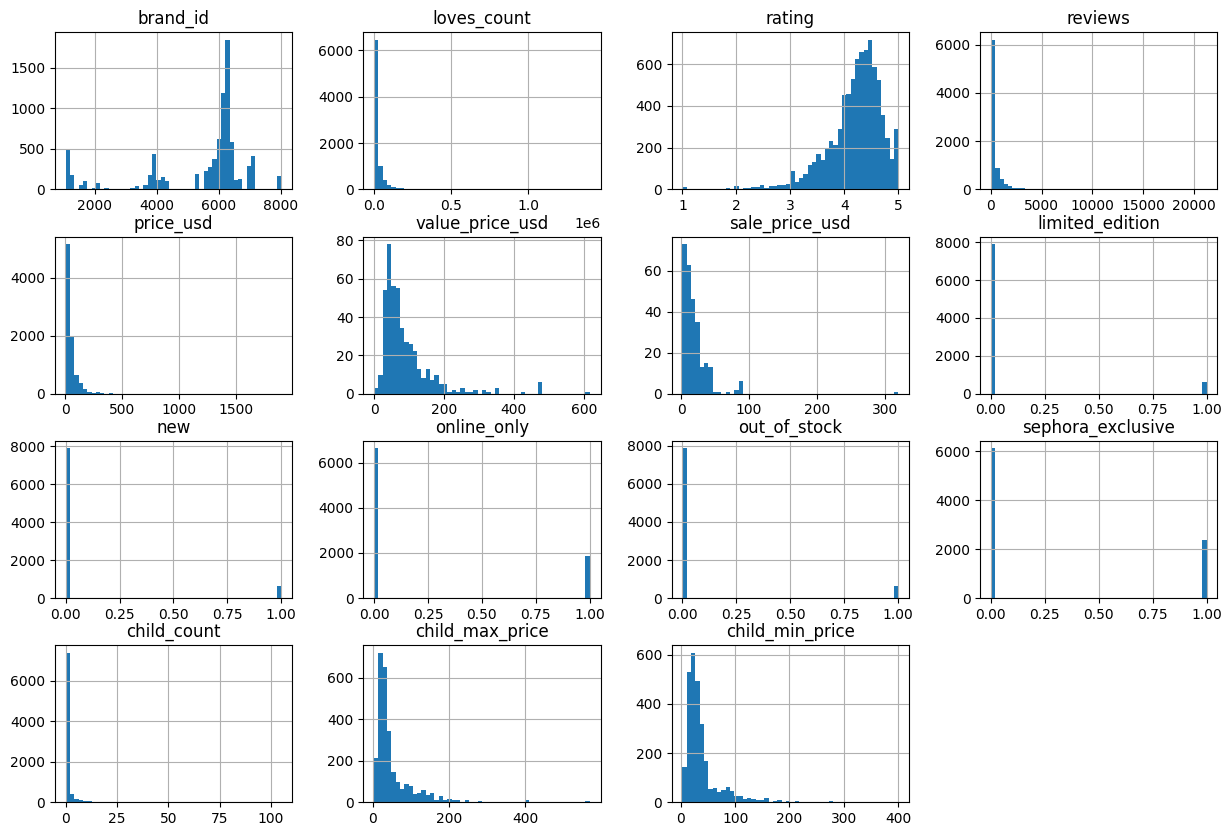

In [13]:
# 전체 히스토그램
df.select_dtypes(include="number").hist(figsize=(15, 10), bins=50)

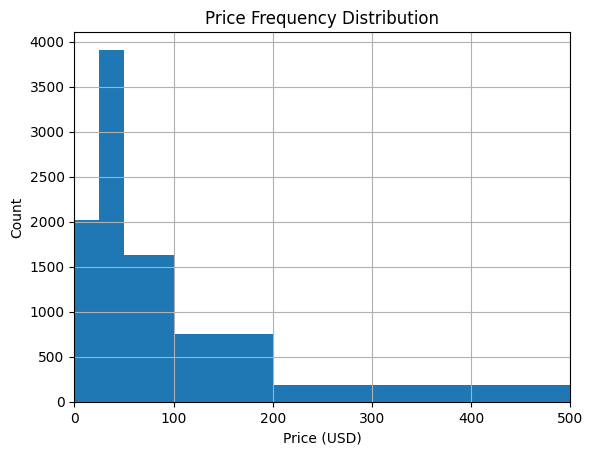

In [14]:
# price_usd 도수분포표를 히스토그램으로 나타내기
df["price_usd"].hist(bins=[0,25,50,100,200,2000] )
plt.title("Price Frequency Distribution")
plt.xlabel("Price (USD)")
plt.ylabel("Count")
plt.xlim(0,500)
plt.show()

## 비대칭도 (왜도,skew)
### 비대칭도(skew)
* 확률 분포의 좌우 비대칭성을 나타내는 지표
* 왜도 > 0: 오른쪽 꼬리가 긴 분포 (중앙값을 포함한 값이 왼쪽네 더 많이 분포)
* 왜도 < 0: 왼쪽 꼬리가 긴 분포 (값이 오른쪽에 더 많이 분포)
* 평균과 중앙값이 같으면 왜도는 0

![skewness](https://upload.wikimedia.org/wikipedia/commons/f/f8/Negative_and_positive_skew_diagrams_%28English%29.svg?utm_source=ko.wikipedia.org&utm_campaign=imageinfo&utm_content=original)

출처 : https://ko.wikipedia.org/wiki/%EB%B9%84%EB%8C%80%EC%B9%AD%EB%8F%84




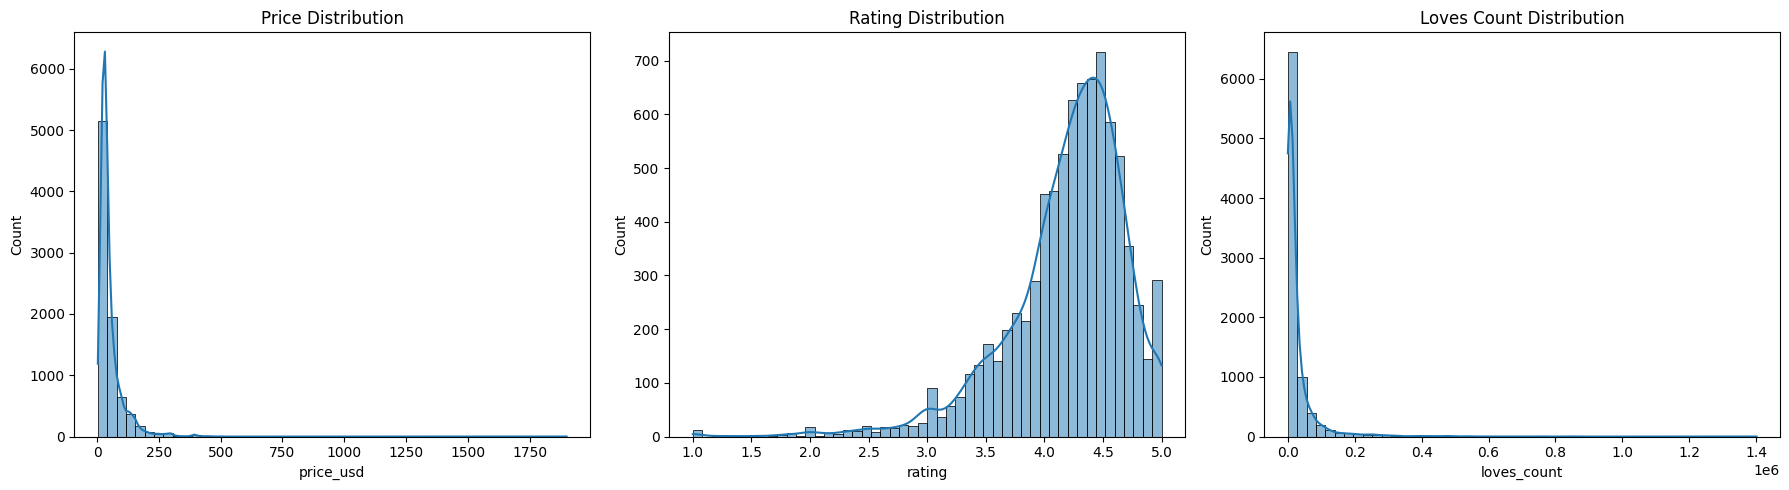

In [15]:

# Price / Rating / Loves Count

fig, axes = plt.subplots(1, 3, figsize= (18,5))
sns.histplot(data=df, x="price_usd", bins=50, kde=True, ax=axes[0])
axes[0].set_title("Price Distribution")

sns.histplot(data=df, x="rating", bins=50, kde=True, ax=axes[1])
axes[1].set_title("Rating Distribution")

sns.histplot(data=df, x="loves_count", bins=50, kde=True, ax=axes[2])
axes[2].set_title("Loves Count Distribution")

plt.tight_layout()
plt.show()

In [16]:
#df.skew(numeric_only = True)
df.skew(numeric_only = True)[["price_usd", "rating", "loves_count"]]

,0
price_usd,7.379939
rating,-1.517629
loves_count,7.252906



### 첨도(kurt)
* 확률분포의 뾰족한 정도를 나타내는 지표
* 관측치가 중심에 얼마나 집중되어 있는지를 측정
* K = 3: 정규분포와 비슷한 모양
* K < 3: 정규분포보다 납작하고 완만한 모양 (꼬리가 얇은 분포)
* K > 3: 정규분포보다 뾰족하고 극단적인 모양 (꼬리가 두꺼운 분포)

<img src="https://upload.wikimedia.org/wikipedia/commons/e/e6/Standard_symmetric_pdfs.png?utm_source=commons.wikimedia.org&utm_campaign=index&utm_content=original" width="500">

출처 : https://ko.wikipedia.org/wiki/%EC%B2%A8%EB%8F%84

* [scipy.stats.kurtosis — SciPy Manual](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kurtosis.html)
* Fisher의 정의를 사용하면 결과에서 3.0을 빼서 정규 분포에 대해 0.0 된다.
* Fisher 정의: 정규분포 기준값이 0 (pandas `.kurt()`가 사용하는 방식)
* Pearson 정의: 정규분포 기준값이 3



In [19]:
# 첨도 (K) 세가지 유형을 보여주기 위한 임의의 더미 데이터 생성
# launch_month_dummy, package_weight_dummy는 가상 컬럼이며 실제 Sephora 데이터가 아님

np.random.seed(42)

# 1-12월 사이 무작위 정수 생성 (제품 출시월이 연중 고르게 분포한다고 가정) -> K가 정규분포보다 납작하고 완만한 모양 예시
df["launch_month_dummy"] = np.random.randint(1,13, size=len(df))

# 평균 1.7oz, 표준편차 0.4인 정규분포 생성 (패키지 용량이 특정 값 주변에 몰린다고 가정) -> K=0인 예시
df["package_weight_dummy"] = np.random.normal(1.7, 0.4, size=len(df))

# # 가상 컬럼 2개 + 실제 컬럼(price_usd)의 첨도 비교
# df[["launch_month_dummy", "package_weight_dummy", "price_usd"]].kurt()


<Axes: xlabel='price_usd', ylabel='Count'>

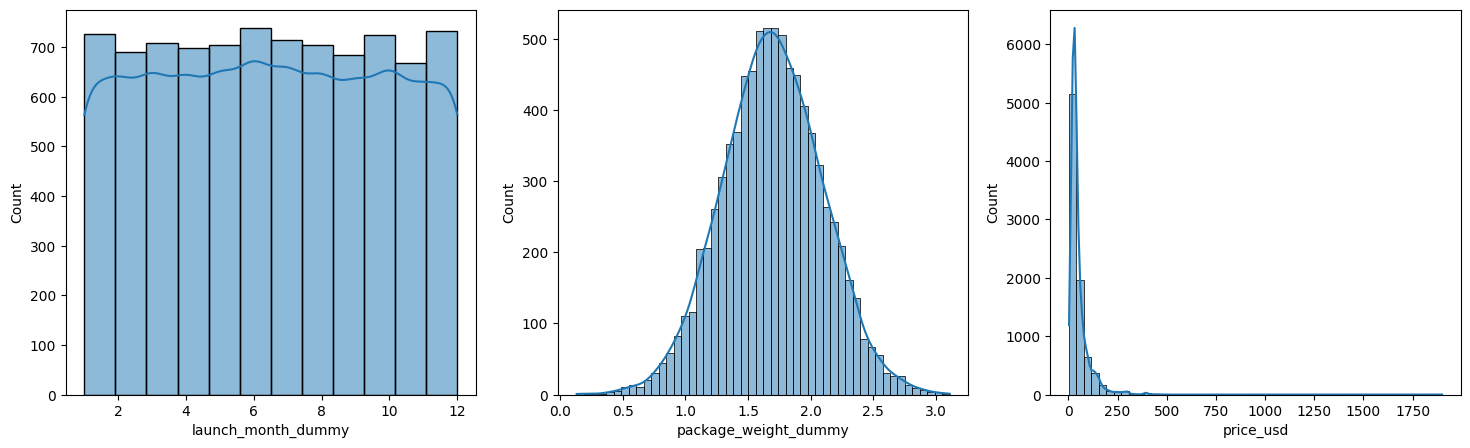

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=df, x="launch_month_dummy", bins=12, kde=True, ax=axes[0])
sns.histplot(data=df, x="package_weight_dummy", bins=50, kde=True, ax=axes[1])
sns.histplot(data=df, x="price_usd", bins=50, kde=True, ax=axes[2])





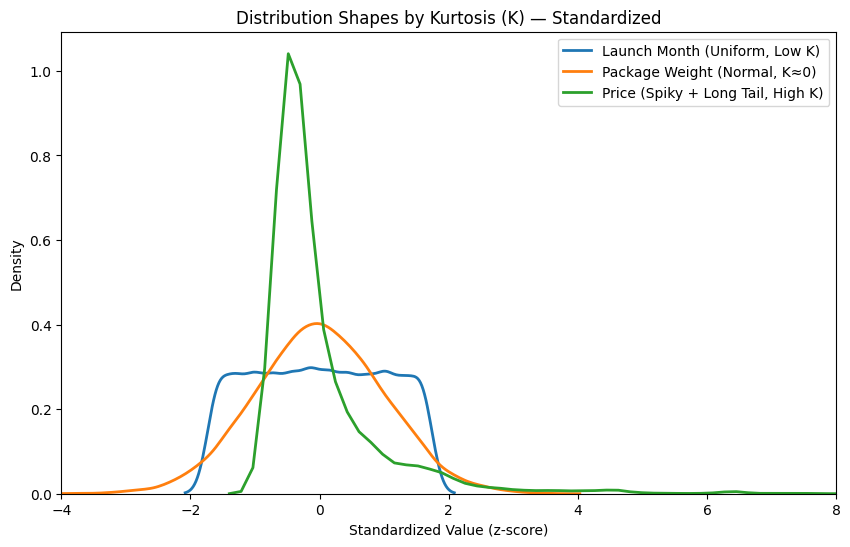

In [25]:
# 세 변수는 원래 단위(개월/oz/달러)가 달라 KDE 곡선 높이가 왜곡되므로,
# z-score(표준화)로 변환해 "표준편차 몇 개만큼 떨어졌는지" 공통 단위로 맞춘 뒤 비교
from scipy.stats import zscore

plt.figure(figsize=(10, 6))  # 세 곡선을 겹쳐 그릴 하나의 도화지 준비

# 각 컬럼을 z-score로 변환 후 KDE 곡선으로 시각화
sns.kdeplot(zscore(df["launch_month_dummy"]), label="Launch Month (Platykurtic distribution)", linewidth=2)
sns.kdeplot(zscore(df["package_weight_dummy"]), label="Package Weight (Mesokurtic distribution)", linewidth=2)
sns.kdeplot(zscore(df["price_usd"]), label="Price (Leptokurtic distribution)", linewidth=2)

# z-score는 대부분 -3~3 사이에 몰리지만, price_usd는 이상치 때문에 꼬리가 길어 범위를 넉넉히 설정
plt.xlim(-4, 8)

plt.title("Distribution Shapes by Kurtosis (K) — Standardized")
plt.xlabel("Standardized Value (z-score)")
plt.ylabel("Density")
plt.legend()  # label로 지정한 이름들을 범례로 표시
plt.show()

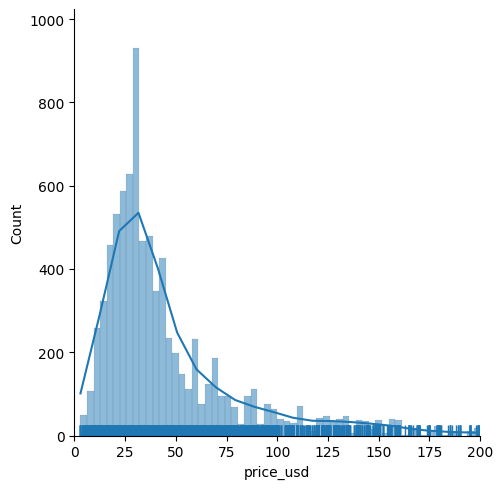

In [ ]:
sns.displot(data=df, x= "price_usd", kde= True, rug= True)
plt.xlim(0, 200)
plt.show()

/tmp/ipykernel_25815/4007307865.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df,x= "price_usd", shade= True, cut = 10)


(0.0, 500.0)

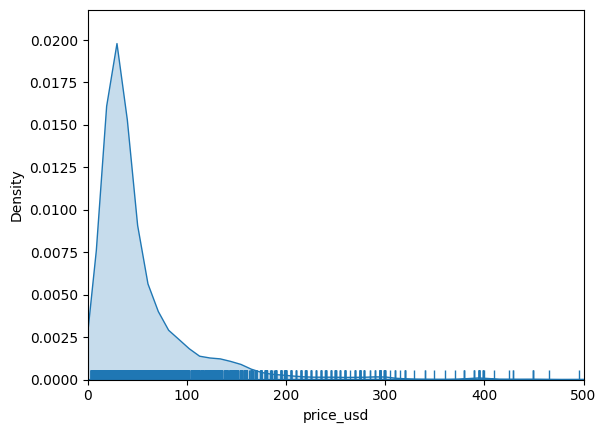

In [ ]:
sns.kdeplot(data=df,x= "price_usd", shade= True, cut = 10)
sns.rugplot(data=df, x= "price_usd")
plt.xlim(0, 500)

In [ ]:
df["price_usd"].agg(["skew","kurt"])

,price_usd
skew,7.379939
kurt,175.725678


<Axes: xlabel='price_usd'>

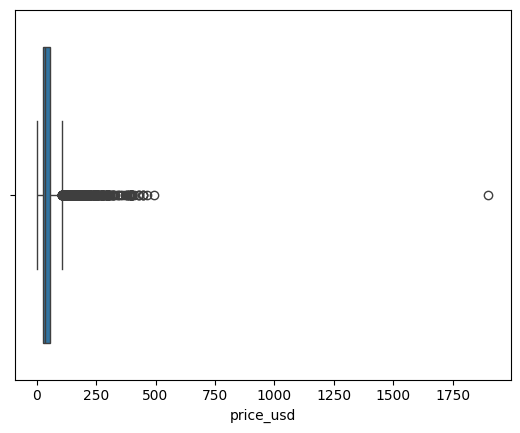

In [ ]:
sns.boxplot(data=df, x = "price_usd")

<Axes: xlabel='price_usd'>

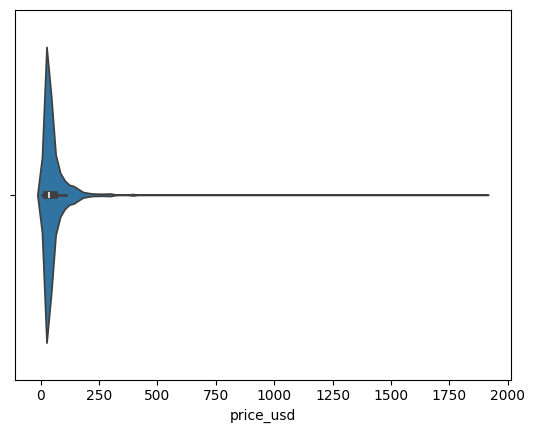

In [ ]:
sns.violinplot(data=df, x="price_usd")

<Axes: xlabel='rating'>

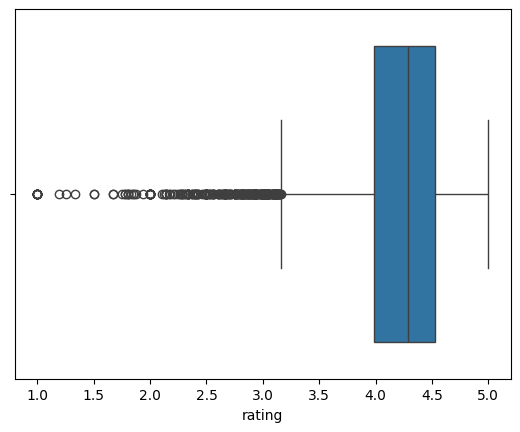

In [ ]:
sns.boxplot(data=df, x = "rating")

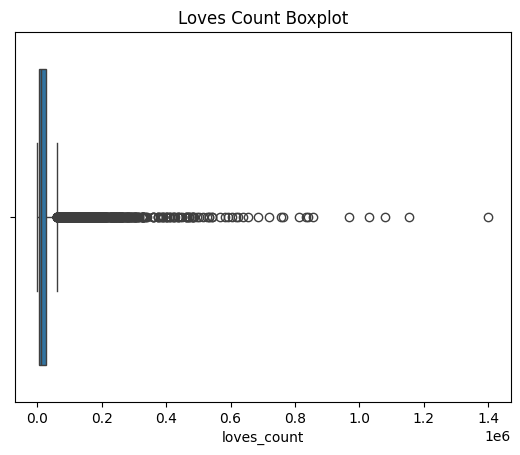

In [ ]:
sns.boxplot(data=df, x="loves_count")
plt.title("Loves Count Boxplot")
plt.show()